In [1]:
ROLE = "Destination"
import paho.mqtt.client as mqtt
import time
import numpy as np
import matplotlib.pyplot as plt
import hmac

import sys
sys.path.append('../../')

import src

conf = src.CONFIG()
rx = src.RX(role=ROLE,conf=conf)



[INFO] [UHD] linux; GNU C++ version 13.3.0; Boost_108300; UHD_4.7.0.0-149-g635ad362
[INFO] [USRP2] Opening a USRP2/N-Series device...
[INFO] [USRP2] Current recv frame size: 1472 bytes
[INFO] [USRP2] Current send frame size: 1472 bytes
[WARNING] [UHD] Unable to set the thread priority. Performance may be negatively affected.
Please see the general application notes in the manual for instructions.
EnvironmentError: OSError: error in pthread_setschedparam


[DESTINATION RX] Publishing 'ready'
[DESTINATION RX] Connected. Subscribing to 'mkashani/feeds/begin'
[DESTINATION RX] Received 'begin'
[DESTINATION RX] 'Begin' detected, disconnecting.

 Recorded Time: 4.070531845092773


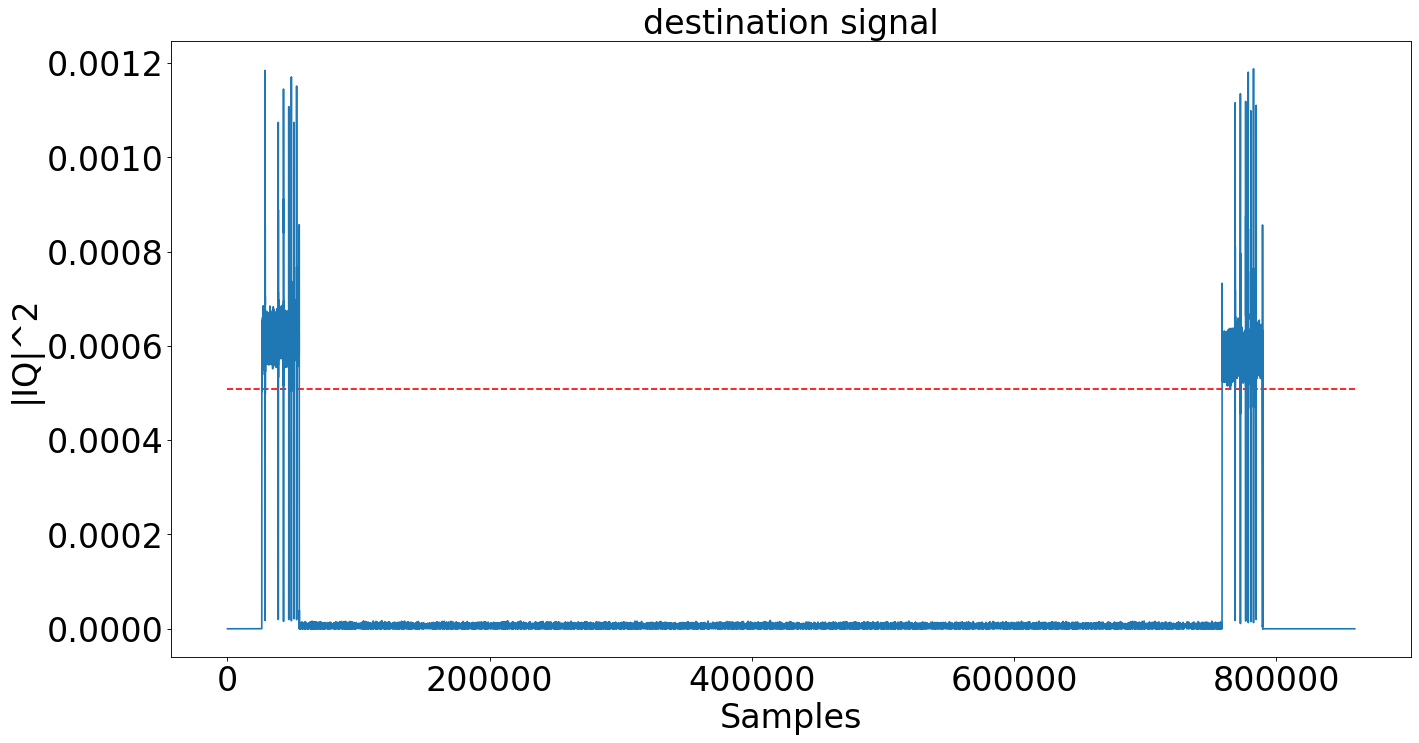


number of frames: 1
# Frame OK ...

file size is: 159989760
Size check failed ...    
Recording is correct
Message:  This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?
recieved MAC:  3776b3b21e2b54891a0731a27165ff9fbfed670657998d1d37acec5b41daedb2
Good MAC
SNR:  13.01765


/home/moh/Documents/PhD/Kim/Superposing_LDPC/Experiments/3_node_test/../../src/rx.py:243: RuntimeWarning: invalid value encountered in log10
  SNR = 10*np.log10(r_signal/r_noise -1)


In [2]:

src.MQTT_RX(conf=conf, role=ROLE).send_ready_and_wait_for_begin()
file = rx.record()

demod = src.rx.Demodulation(conf=conf)
pp = src.PostProcessing(file=file, conf=conf, demod=demod, role=ROLE, plot=True)

if pp.check():
    print("Recording is correct")
    for i in range(len(pp.Frames)):
        frame = pp.frameByNumber(i)
        hard_decision,rs, SNR = demod.decode(frame)
        index = demod.detect_message_indices(received=list(hard_decision), preamble=conf.PREAMBLE, repeat=conf.PREAMBLE_REPEAT)
        if index[0] is None or index[1] is None:
            print("No preamble detected!")
            continue

        msg_hard_decision = hard_decision[index[0]:index[1]]
        print("Message: ", pp.bits_to_string(msg_hard_decision[0:-256]))
        print("recieved MAC: ", pp.binary_list_to_hex(msg_hard_decision[-256:]))
        expected_MAC = hmac.new(conf.MAC_KEY.encode('utf-8'), msg=pp.bits_to_string(msg_hard_decision[0:-256]).encode('utf-8'), digestmod='sha256').hexdigest()
        if pp.binary_list_to_hex(msg_hard_decision[-256:]) == expected_MAC:
            print("Good MAC")
        else:
            print("MAC is not correct")

        SNR = SNR[index[0]+10:index[1]-10]
        print("SNR: ", np.nanmean(SNR))